#Task 9: Anchor-Free Object Detection (YOLOv8-style) Loss Backpropagation
#Objective:
 Architect state-of-the-art multi-task object localization pipelines by tracking
regression outputs and classification predictions simultaneously.
#Required Tech Stack:
 PyTorch, OpenCV, NumPy, Matplotlib.
#Task Description:
Students will write a custom loss-tracking module for an anchor-free
object detector. The module must implement Complete Intersection over Union (CIoU)
bounding box regression loss, compute classification loss, and handle complex assignment
strategies to match target labels with dynamic network outputs.

Import Libraries

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Synthetic Predictions

In [2]:
pred_boxes = torch.tensor([
    [50.,50.,40.,40.],
    [120.,100.,35.,45.],
    [200.,220.,60.,70.]
])

gt_boxes = torch.tensor([
    [48.,52.,42.,38.],
    [118.,98.,34.,46.],
    [198.,218.,62.,68.]
])

pred_scores = torch.tensor([
    [0.90],
    [0.70],
    [0.80]
])

gt_scores = torch.tensor([
    [1.0],
    [1.0],
    [1.0]
])

IoU Function

In [3]:
def box_xywh_to_xyxy(box):
    x, y, w, h = box.unbind(-1)
    return torch.stack([
        x - w / 2,
        y - h / 2,
        x + w / 2,
        y + h / 2
    ], dim=-1)


def iou(box1, box2):
    box1 = box_xywh_to_xyxy(box1)
    box2 = box_xywh_to_xyxy(box2)

    x1 = torch.max(box1[:, 0], box2[:, 0])
    y1 = torch.max(box1[:, 1], box2[:, 1])
    x2 = torch.min(box1[:, 2], box2[:, 2])
    y2 = torch.min(box1[:, 3], box2[:, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (box1[:, 2]-box1[:, 0]) * (box1[:, 3]-box1[:, 1])
    area2 = (box2[:, 2]-box2[:, 0]) * (box2[:, 3]-box2[:, 1])

    union = area1 + area2 - inter

    return inter / (union + 1e-7)

CIoU Loss

In [4]:
def ciou_loss(pred, target):

    iou_score = iou(pred, target)

    center_dist = (
        (pred[:, 0]-target[:, 0])**2 +
        (pred[:, 1]-target[:, 1])**2
    )

    enclosing_w = torch.max(
        pred[:, 0]+pred[:, 2]/2,
        target[:, 0]+target[:, 2]/2
    ) - torch.min(
        pred[:, 0]-pred[:, 2]/2,
        target[:, 0]-target[:, 2]/2
    )

    enclosing_h = torch.max(
        pred[:, 1]+pred[:, 3]/2,
        target[:, 1]+target[:, 3]/2
    ) - torch.min(
        pred[:, 1]-pred[:, 3]/2,
        target[:, 1]-target[:, 3]/2
    )

    c2 = enclosing_w**2 + enclosing_h**2 + 1e-7

    loss = 1 - iou_score + center_dist / c2

    return loss.mean()

Classification Loss

In [5]:
criterion = nn.BCELoss()

cls_loss = criterion(
    pred_scores,
    gt_scores
)

print("Classification Loss:", cls_loss.item())

Classification Loss: 0.22839301824569702


Simple Target Assignment

In [6]:
def assign_targets(pred_boxes, gt_boxes):

    assigned = []

    for i in range(len(pred_boxes)):
        assigned.append(i)

    return assigned

matches = assign_targets(pred_boxes, gt_boxes)

print("Assignments:", matches)

Assignments: [0, 1, 2]


Combined Detection Loss

In [7]:
bbox_loss = ciou_loss(
    pred_boxes,
    gt_boxes
)

total_loss = bbox_loss + cls_loss

print("CIoU Loss :", bbox_loss.item())
print("Total Loss:", total_loss.item())

CIoU Loss : 0.15901656448841095
Total Loss: 0.3874095678329468


Visualization

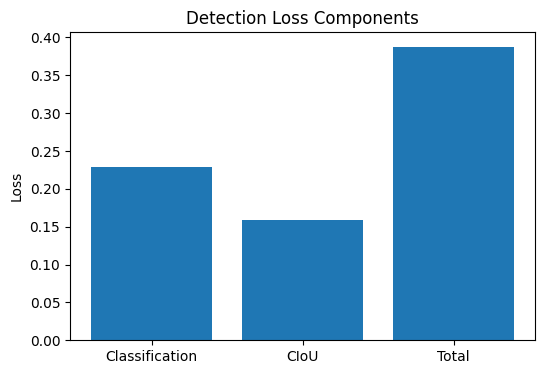

In [8]:
labels = ["Classification", "CIoU", "Total"]

values = [
    cls_loss.item(),
    bbox_loss.item(),
    total_loss.item()
]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.ylabel("Loss")

plt.title("Detection Loss Components")

plt.show()